# 05. Биполярная и мостовая ШИМ

Для знакового входа `[-1, 1]` в текущем коде есть два связанных подхода:

- `pwm_kind*_bipolar(...)`: две логические ветви `positive` и `negative`, полезный сигнал `positive - negative`.
- `pwm_kind*_bridge(...)`: физические выходы `plus` и `minus` для мостовой схемы, с режимами `regular`, `bipolar`, `three_level`.

In [1]:
from pathlib import Path
import sys

HERE = Path.cwd().resolve()
if (HERE / "tutorial_helpers.py").exists():
    TUTORIAL_DIR = HERE
elif (HERE / "tutorials" / "tutorial_helpers.py").exists():
    TUTORIAL_DIR = HERE / "tutorials"
else:
    raise RuntimeError("Run this notebook from the repository root or from the tutorials folder")

path_text = str(TUTORIAL_DIR)
if path_text not in sys.path:
    sys.path.insert(0, path_text)

import matplotlib.pyplot as plt
import numpy as np

from tutorial_helpers import (
    configure_plots,
    grouped_fifo_channel_waveforms,
    load_pwm_lab,
    plot_bitstream,
    plot_channel_stack,
    plot_moving_average_reconstruction,
    plot_pwm_carrier_output,
    plot_spectra,
    print_peak_table,
    pwm_kind2_channel_waveforms,
    show_grouped_mapping,
    time_us,
)

pl = load_pwm_lab()
configure_plots()
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 300,
        "font.family": "DejaVu Sans",
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.grid": True,
        "grid.alpha": 0.28,
        "grid.linewidth": 0.8,
        "lines.linewidth": 1.5,
        "legend.frameon": False,
    }
)

PWM_FIGSIZE = (13.2, 7.2)
PWM_COLORS = {
    "input": "tab:orange",
    "carrier": "tab:blue",
    "plus": "tab:green",
    "minus": "tab:red",
    "diff": "tab:purple",
}


def style_pwm_axes(axes):
    for ax in np.atleast_1d(axes):
        ax.grid(True, alpha=0.28, linewidth=0.8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="both", labelsize=12)


def set_binary_axis(ax):
    ax.set_ylim(-0.15, 1.15)
    ax.set_yticks([0.0, 0.5, 1.0])

## Знаковый FIFO-вход

In [2]:
config = pl.PwmConfig(f_clk=80e6, f_pwm=1e6, resolution_bits=8)
f_signal = 50e3
n_periods = 128

_, x_signed = pl.sine_signed(freq=f_signal, sample_rate=config.actual_f_pwm, n_samples=n_periods, amplitude=0.85)

bipolar = pl.pwm_kind2_bipolar_latched(x_signed, config)
bridge_regular = pl.pwm_kind2_bridge_latched(x_signed, config, mode="regular")
bridge_bipolar = pl.pwm_kind2_bridge_latched(x_signed, config, mode="bipolar")
bridge_three = pl.pwm_kind2_bridge_latched(x_signed, config, mode="three_level")

## Биполярные ветви: positive / negative / differential

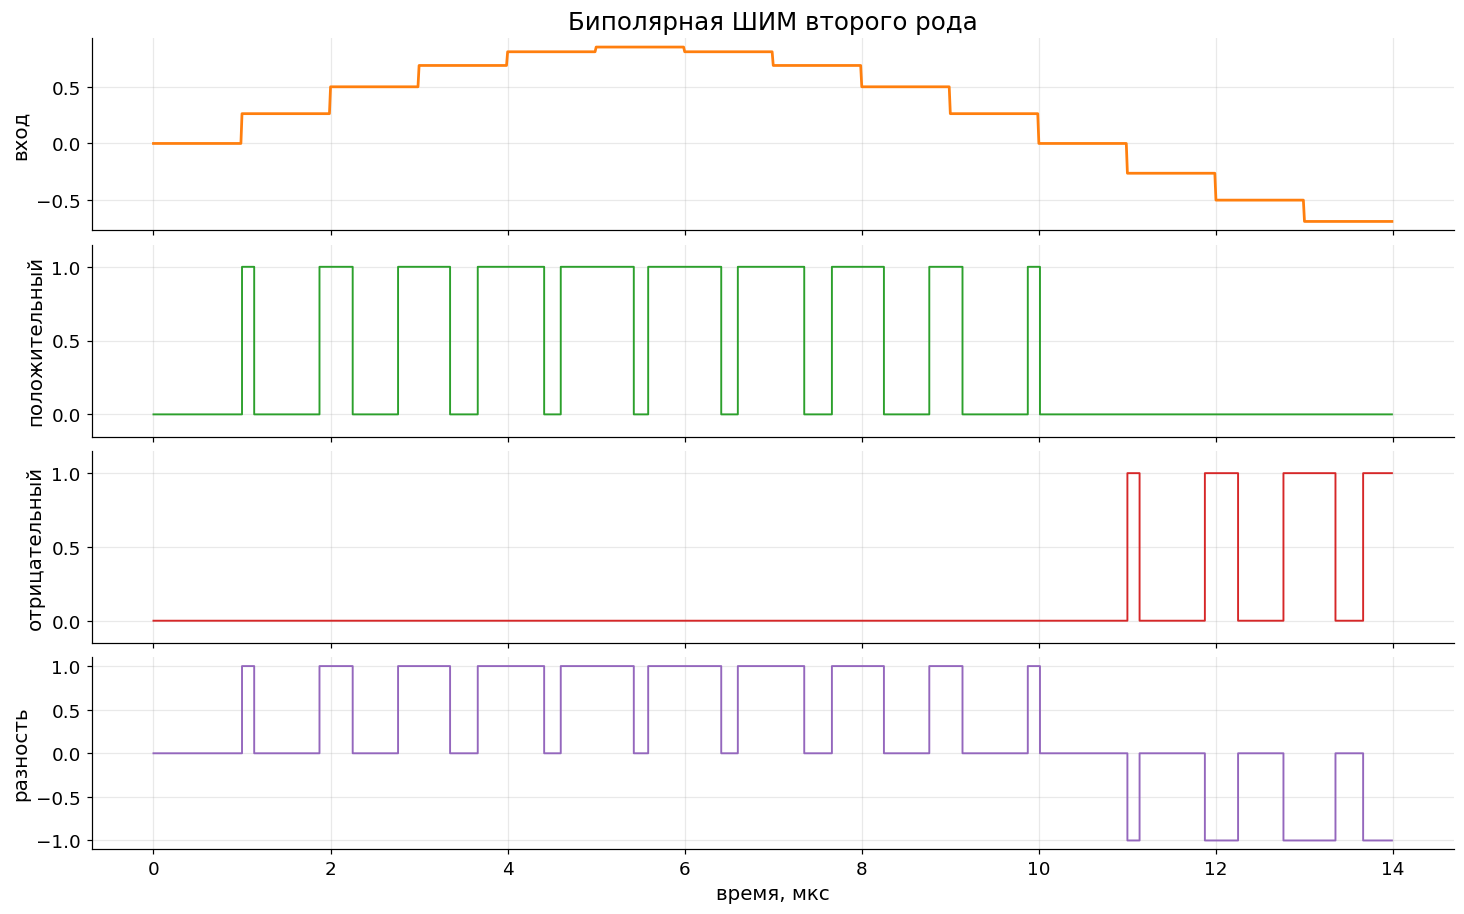

In [3]:
n = 14 * config.period_samples
t = time_us(config.f_clk, n)
x_latched = np.repeat(x_signed, config.period_samples)

fig, axes = plt.subplots(4, 1, figsize=(13.2, 8.2), sharex=True, constrained_layout=True)
axes[0].plot(t, x_latched[:n], color=PWM_COLORS["input"], linewidth=1.8)
axes[0].set_title("Биполярная ШИМ второго рода")
axes[0].set_ylabel("вход")

axes[1].step(t, bipolar.positive[:n], where="post", color=PWM_COLORS["plus"], linewidth=1.25)
axes[1].set_ylabel("положительный")
set_binary_axis(axes[1])

axes[2].step(t, bipolar.negative[:n], where="post", color=PWM_COLORS["minus"], linewidth=1.25)
axes[2].set_ylabel("отрицательный")
set_binary_axis(axes[2])

axes[3].step(t, bipolar.differential[:n], where="post", color=PWM_COLORS["diff"], linewidth=1.25)
axes[3].set_ylabel("разность")
axes[3].set_xlabel("время, мкс")
style_pwm_axes(axes)

## Мостовые режимы

`three_level` обычно ближе к логике разделения по модулю и знаку: около нуля обе ветви выключены. `regular` всегда держит одну из физических ветвей активной.

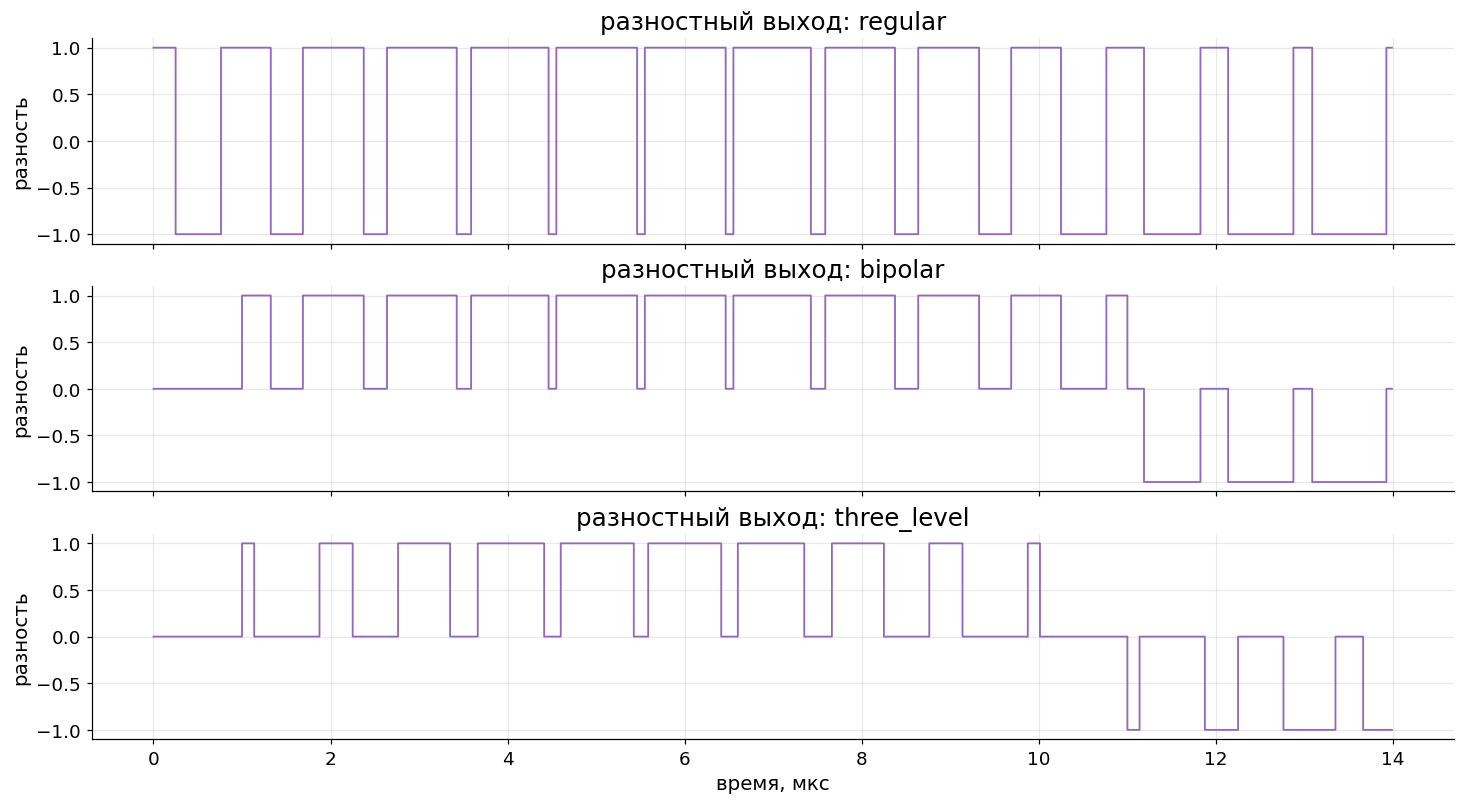

In [4]:
n = 14 * config.period_samples
t = time_us(config.f_clk, n)

fig, axes = plt.subplots(3, 1, figsize=PWM_FIGSIZE, sharex=True, constrained_layout=True)
for ax, obj, title in [
    (axes[0], bridge_regular, "разностный выход: regular"),
    (axes[1], bridge_bipolar, "разностный выход: bipolar"),
    (axes[2], bridge_three, "разностный выход: three_level"),
]:
    ax.step(t, obj.differential[:n], where="post", color=PWM_COLORS["diff"], linewidth=1.2)
    ax.set_ylabel("разность")
    ax.set_title(title)
axes[2].set_xlabel("время, мкс")
style_pwm_axes(axes)

## Спектры разностных выходов

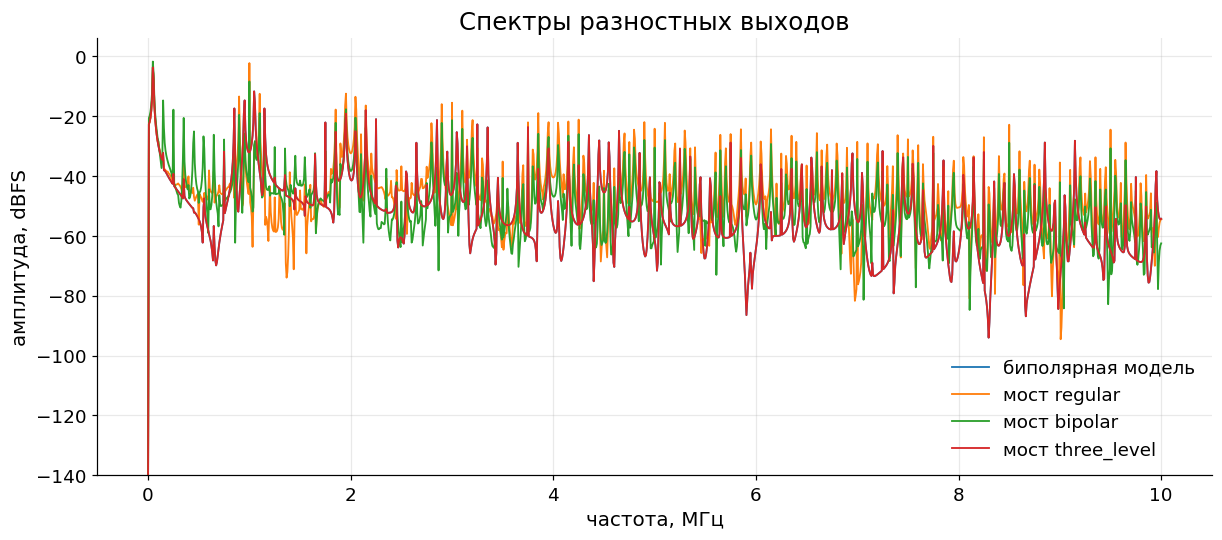

In [5]:
fig, ax = plot_spectra(
    {
        "биполярная модель": bipolar.differential,
        "мост regular": bridge_regular.differential,
        "мост bipolar": bridge_bipolar.differential,
        "мост three_level": bridge_three.differential,
    },
    sample_rate=config.f_clk,
    f_max=10e6,
    f_scale=1e6,
    f_unit="MHz",
    title="Спектры разностных выходов",
);
ax.set_xlabel("частота, МГц")
ax.set_ylabel("амплитуда, dBFS")
style_pwm_axes([ax])

## ШИМ первого рода: выходы plus / minus для мостовых режимов

Ниже один и тот же знаковый синус подается в `pwm_kind1_bridge(...)`. Для каждого режима построена отдельная фигура:

- верхний подграфик: входной синус и треугольная опора;
- средний подграфик: физический выход `plus`;
- нижний подграфик: физический выход `minus`.

Разница режимов:

| режим | Что происходит |
|---|---|
| `regular` | `plus` и `minus` комплементарны: на каждом такте активна одна из ветвей. |
| `bipolar` | Используется сравнение режима `regular`, но `plus` разрешен только при `input > 0`, а `minus` только при `input < 0`. Около нуля обе ветви выключены. |
| `three_level` | Сравнивается `abs(input)` с опорой, потом импульс направляется в `plus` или `minus` по знаку входа. Это самый явный режим разделения по модулю и знаку. |

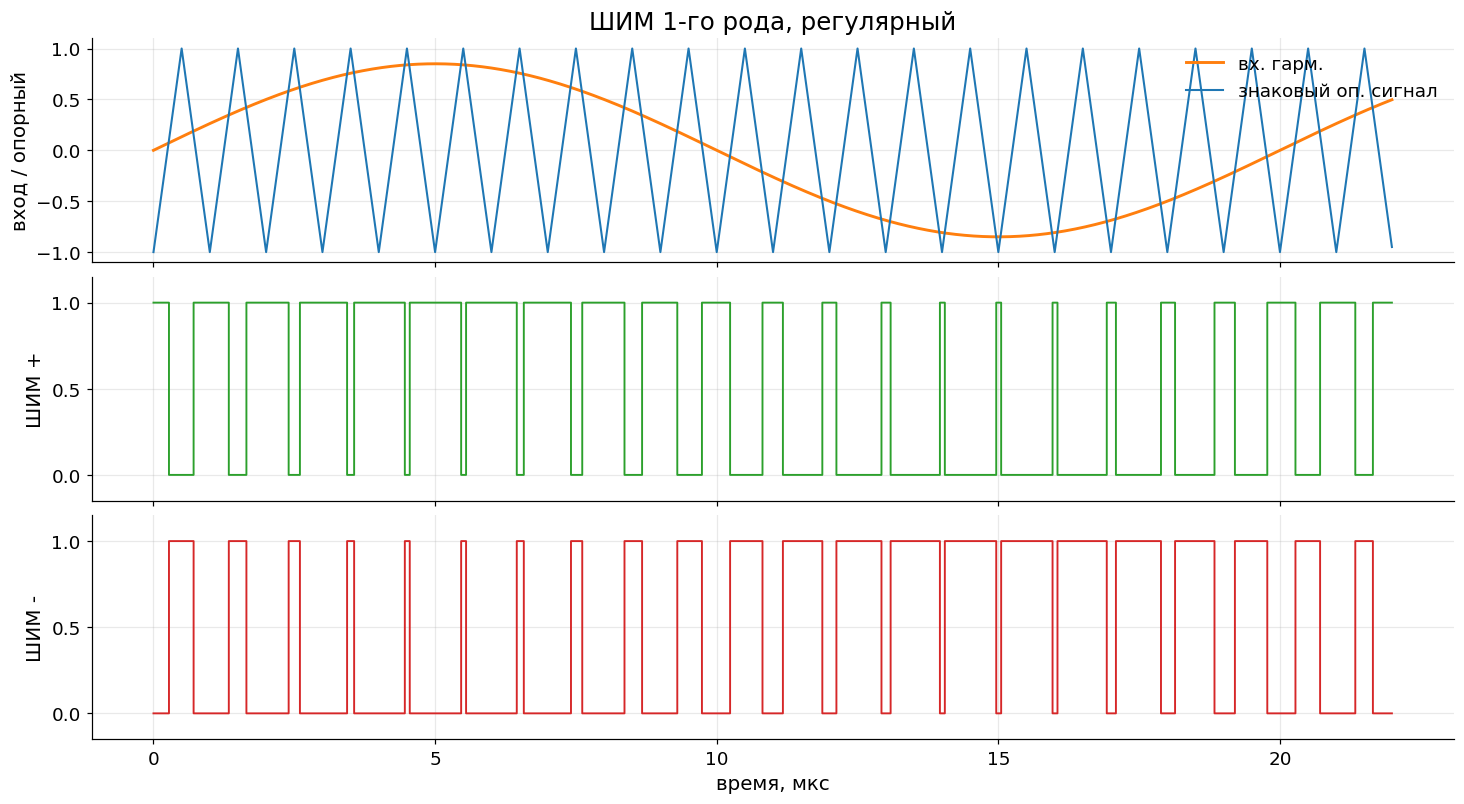

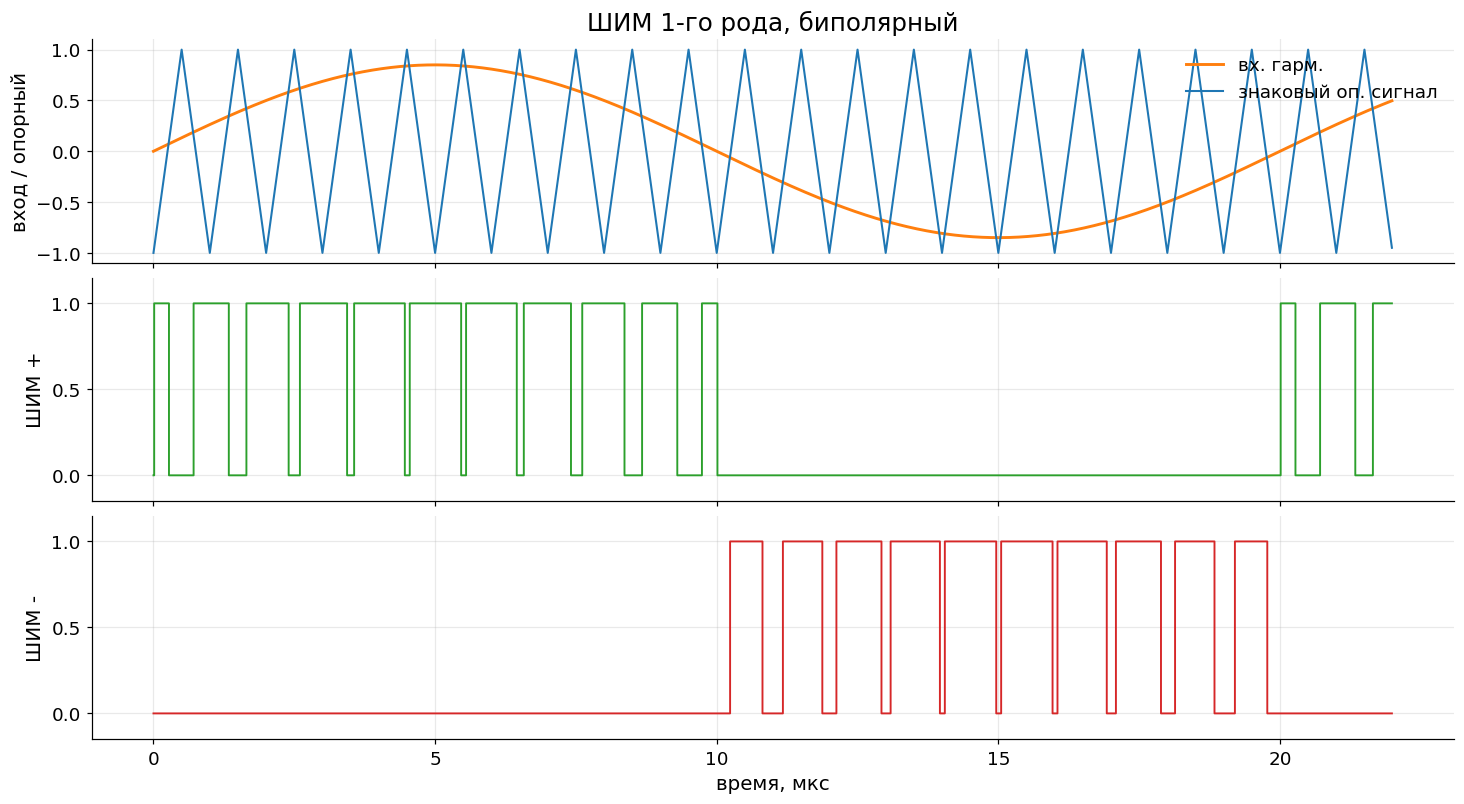

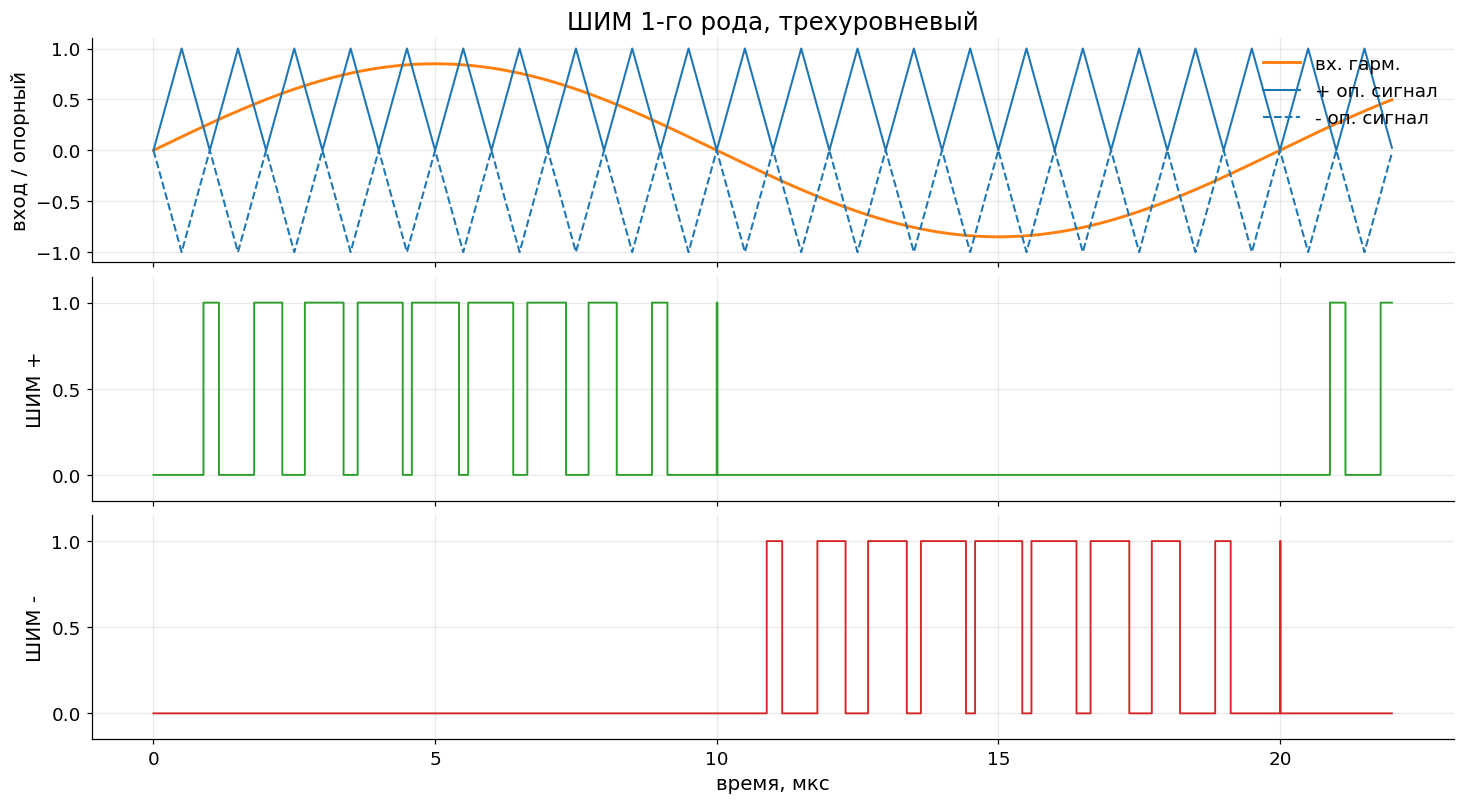

In [6]:
kind1_config = pl.PwmConfig(f_clk=80e6, f_pwm=1e6, resolution_bits=8)
kind1_f_signal = 50e3
kind1_periods_to_plot = 22
kind1_n = kind1_periods_to_plot * kind1_config.period_samples

_, x_kind1_bridge = pl.sine_signed(
    freq=kind1_f_signal,
    sample_rate=kind1_config.f_clk,
    n_samples=kind1_n,
    amplitude=0.85,
)
carrier_unit = np.resize(pl.triangle_carrier(kind1_config.period_samples), kind1_n)
t = time_us(kind1_config.f_clk, kind1_n)


def plot_bridge_kind1_mode(mode, title):
    bridge = pl.pwm_kind1_bridge(x_kind1_bridge, kind1_config, mode=mode)

    fig, axes = plt.subplots(3, 1, figsize=PWM_FIGSIZE, sharex=True, constrained_layout=True)
    axes[0].plot(t, x_kind1_bridge, color=PWM_COLORS["input"], linewidth=1.9, label="вх. гарм.")
    if mode == "three_level":
        axes[0].plot(t, carrier_unit, color=PWM_COLORS["carrier"], linewidth=1.35, label="+ оп. сигнал")
        axes[0].plot(
            t,
            -carrier_unit,
            color=PWM_COLORS["carrier"],
            linewidth=1.35,
            linestyle="--",
            label="- оп. сигнал",
        )
    else:
        axes[0].plot(
            t,
            2.0 * carrier_unit - 1.0,
            color=PWM_COLORS["carrier"],
            linewidth=1.35,
            label="знаковый оп. сигнал",
        )
    axes[0].set_title(title)
    axes[0].set_ylabel("вход / опорный")
    axes[0].set_ylim(-1.1, 1.1)
    axes[0].legend(loc="upper right")

    axes[1].step(t, bridge.plus, where="post", color=PWM_COLORS["plus"], linewidth=1.25)
    axes[1].set_ylabel("ШИМ +")
    set_binary_axis(axes[1])

    axes[2].step(t, bridge.minus, where="post", color=PWM_COLORS["minus"], linewidth=1.25)
    axes[2].set_ylabel("ШИМ -")
    axes[2].set_xlabel("время, мкс")
    set_binary_axis(axes[2])

    style_pwm_axes(axes)
    return fig, axes


for mode, title in [
    ("regular", "ШИМ 1-го рода, регулярный"),
    ("bipolar", "ШИМ 1-го рода, биполярный"),
    ("three_level", "ШИМ 1-го рода, трехуровневый"),
]:
    plot_bridge_kind1_mode(mode, title)
    plt.show()